In [11]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm


from copy import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375


In [12]:
def energies(t1, t2, Jc, m, k):
    ar = np.array(
        [
            -2 * t1 * np.cos(k[0]) - 2 * t2 * np.cos(k[1]) - Jc * m,
            -2 * t1 * np.cos(k[0]) - 2 * t2 * np.cos(k[1]) + Jc * m,
            -2 * t1 * np.cos(k[1]) - 2 * t2 * np.cos(k[0]) + Jc * m,
            -2 * t1 * np.cos(k[1]) - 2 * t2 * np.cos(k[0]) - Jc * m,
        ]
    )
    return ar


m_contributions = np.array([1, -1, -1, 1])

kx_walk = np.concatenate(
    [
        np.linspace(0, 0, 100),
        np.linspace(0, np.pi, 100),
        np.linspace(np.pi, np.pi, 100),
        np.linspace(np.pi, 0, 100),
    ]
)

ky_walk = np.concatenate(
    [
        np.linspace(0, np.pi, 100),
        np.linspace(np.pi, np.pi, 100),
        np.linspace(np.pi, 0, 100),
        np.linspace(0, 0, 100),
    ]
)

k_walk = np.array([kx_walk, ky_walk]).T

k_resolution = 500

kx = np.linspace(-np.pi, np.pi, k_resolution, endpoint=False)
ky = np.linspace(-np.pi, np.pi, k_resolution, endpoint=False)

kx, ky = np.meshgrid(kx, ky)


100%|██████████| 400/400 [00:00<00:00, 120482.70it/s]

Fermi level: -4.68144047822064


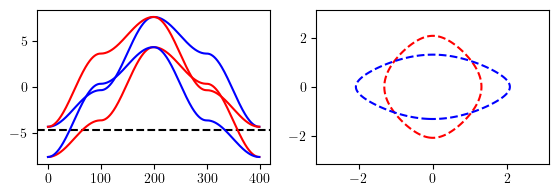

In [13]:
t1 = 2
t2 = 1
Jc = 1
m = 1.65
filling = 0.1

energies_walk = np.array([energies(t1, t2, Jc, m, k) for k in tqdm(k_walk)])
energy_values = energies(t1, t2, Jc, m, np.array([kx, ky]))

colours = ["r", "b", "r", "b"]

fermi_level = np.percentile(energy_values, 100 * filling)
print(f"Fermi level: {fermi_level}")

fig, ax = plt.subplots(1, 2, figsize=(aps_figwidth, 2))
ax[0].axhline(fermi_level, color="k", linestyle="--")
for i in range(4):
    ax[0].plot(energies_walk[:, i], color=colours[i])
    ax[1].contour(kx, ky, energy_values[i], levels=[fermi_level], colors=colours[i])


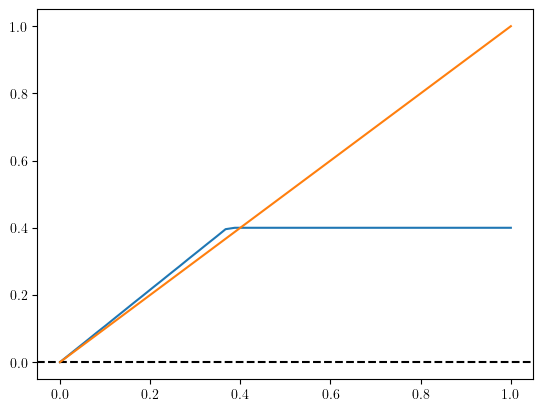

In [14]:
t1 = 2
t2 = 1
Jc = 4
# m = 2
filling = 0.1

m_values = np.linspace(0, 1, 50)
measured_m_values = m_values * 0

for i, m in enumerate(m_values):
    energy_values = energies(t1, t2, Jc, m, np.array([kx, ky]))
    fermi_level = np.percentile(energy_values, 100 * filling)
    measured_m_values[i] = (
        np.mean(m_contributions[:, None, None] * (energy_values < fermi_level)) * 4
    )


plt.plot(m_values, measured_m_values)
plt.axhline(0, color="k", linestyle="--")
plt.plot(m_values, m_values)


100%|██████████| 400/400 [00:00<00:00, 177161.73it/s]


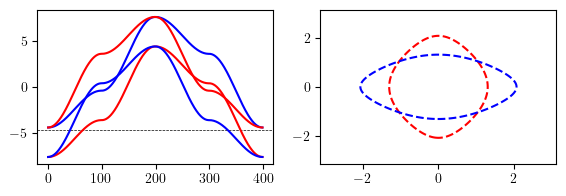

In [15]:
new_m = m

for x in range(20):
    new_energy_values = energies(t1, t2, Jc, new_m, np.array([kx, ky]))
    fermi_level = np.percentile(new_energy_values, 100 * filling)
    new_m = (
        np.mean(m_contributions[:, None, None] * (new_energy_values < fermi_level)) * 4
    )
    # print(new_m)

new_energies_walk = np.array([energies(t1, t2, Jc, new_m, k) for k in tqdm(k_walk)])
fig, ax = plt.subplots(1, 2, figsize=(aps_figwidth, 2))
ax[0].axhline(fermi_level, color="k", linestyle="--", linewidth=0.5)
for i in range(4):
    ax[0].plot(new_energies_walk[:, i], color=colours[i])
    ax[1].contour(kx, ky, new_energy_values[i], levels=[fermi_level], colors=colours[i])